<a href="https://colab.research.google.com/github/jas-ren/6.172/blob/main/Intro_to_kernels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 0: Imports and Setup

In [ ]:
import os
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/content/inductor_cache"

import torch
torch.manual_seed(0)

import time

In [ ]:
import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()

print(DEVICE)

cuda:0


## Section 1: Peeking under the hood of `torch.compile()`

In [ ]:
@torch.compile
def fn(x, y):
    return (x + y)

In [ ]:
a = torch.arange(10, device="cuda")
b = torch.arange(0, 20, 2, device="cuda")
print(a)
print(b)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], device='cuda:0')
tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18], device='cuda:0')


In [ ]:
fn(a, b)

tensor([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27], device='cuda:0')

### 1.1 What files were generated?

In [ ]:
import glob
for path in glob.glob("/content/inductor_cache/**/*.py", recursive=True):
    src = open(path).read()
    if "@triton.jit" in src:
        print(path)

/content/inductor_cache/pv/cpvrk4hkonadfcky67cwzsvboyons5rw5hqxvihfdzlqqoar4win.py
/content/inductor_cache/6m/c6mhgpvn4vaat7wn6nxhnoahynnui36nromg4i2pozc2m3mfvkv3.py


Let's check these source files out!

## Section 2: Vector Addition

First, let's see how many blocks we will have for a given array size

In [ ]:
num_elements = 1024
BLOCK_SIZE = 256

num_blocks = triton.cdiv(num_elements, BLOCK_SIZE)  # ceiling division
print(f"{num_elements} elements / {BLOCK_SIZE} per block = {num_blocks} blocks")

1024 elements / 256 per block = 4 blocks


Now, given a program id, we want to operate on the elements corresponding to that block

In [ ]:
pid = 1
block_start = pid * BLOCK_SIZE
offsets = block_start + torch.arange(0, BLOCK_SIZE)
print(offsets[:3], "...", offsets[-3:])

tensor([256, 257, 258]) ... tensor([509, 510, 511])


### 2.1 The Vector Addition Kernel

Let's bring it together in the Vector Addition Kernel

In [ ]:
@triton.jit
def add_kernel(x_ptr,  # Pointer to first memory entry of input vector x.
               y_ptr,  # Pointer to first memory entry of input vector y.
               output_ptr,  # Pointer to first memory entry of output vector.
               n_elements,  # Size of the vector.
               BLOCK_SIZE: tl.constexpr,  # Number of elements each program should process.
               # NOTE: `constexpr` so it can be used by the compiler as a shape value.
               ):
    pid = tl.program_id(axis=0)  # We use a 1D launch grid so axis is 0.

    block_start = pid * BLOCK_SIZE # <-- Find the starting index of the first element corresponding to block pid
    offsets = block_start + tl.arange(0, BLOCK_SIZE) # <-- Create a vector of addresses for the program to run on

    x = tl.load(x_ptr + offsets) # <-- Read x elements corresponding to this block
    y = tl.load(y_ptr + offsets) # <-- Read y elements corresponding to this block
    output = x + y

    tl.store(output_ptr + offsets, output)  # <-- Write output elements corresponding to this block

### 2.2 The Driver Function

In [ ]:
def add(x: torch.Tensor, y: torch.Tensor):
    output = torch.empty_like(x)
    num_elements = x.numel()
    BLOCK_SIZE = 256

    # The SPMD grid denotes the number of instances of the kernel that run in parallel.
    # It is analogous to CUDA launch grids.
    # In this case, we use a 1D grid where the size is the number of blocks:
    grid = (triton.cdiv(num_elements, BLOCK_SIZE),)

    #  Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    add_kernel[grid](x, y, output, num_elements, BLOCK_SIZE = BLOCK_SIZE)
    return output

In [ ]:
size = 1024
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([1.3713, 1.3076, 0.4940,  ..., 0.8458, 0.5854, 1.2481], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.8458, 0.5854, 1.2481], device='cuda:0')
The maximum difference between torch and triton is 0.0


### Ex 2.3. Vector Size Not Divisible By Block Size

In [ ]:
size = 1000
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([0.8068, 0.9078, 1.0840, 1.6290, 1.3635, 1.0957, 0.5964, 1.4709, 0.6536,
        1.3458, 0.5217, 1.0139, 1.0369, 1.3876, 0.8137, 0.7248, 1.3211, 1.3747,
        0.9541, 0.8868, 0.4936, 1.6252, 0.9131, 1.1045, 0.3141, 0.5656, 0.4229,
        0.8435, 1.0087, 1.5332, 1.6892, 0.2598, 0.7024, 0.9540, 0.5527, 0.4805,
        1.2927, 0.8230, 1.0410, 1.6758, 0.6703, 1.1547, 0.8833, 1.0810, 0.3684,
        1.5230, 0.6953, 1.1999, 0.5002, 0.8039, 0.6832, 0.7491, 0.5632, 0.1834,
        0.8645, 1.0803, 1.2487, 0.7760, 0.5021, 0.5596, 1.1736, 0.5612, 0.8127,
        0.5832, 0.6965, 1.2071, 0.5894, 0.8302, 1.3249, 1.1364, 0.2607, 0.7566,
        1.5537, 0.9603, 0.3906, 0.5128, 0.9290, 0.9895, 0.3923, 0.5233, 0.2522,
        0.8996, 0.8110, 0.3831, 1.0551, 0.7379, 1.3399, 0.9609, 0.7938, 0.7754,
        0.7953, 0.3643, 1.8121, 1.3250, 1.3297, 0.9856, 0.4475, 0.7100, 0.2953,
        0.9433, 1.1156, 0.6690, 0.8441, 1.0667, 0.2112, 0.6074, 1.9003, 0.3070,
        0.9733, 0.7055, 1.5609, 1.2667, 

But wait!

In [ ]:
pid = 3
block_start = pid * BLOCK_SIZE
offsets = block_start + torch.arange(0, BLOCK_SIZE)
print(offsets[:3], "...", offsets[-3:])

tensor([768, 769, 770]) ... tensor([1021, 1022, 1023])


Our new vector has 1000 elements, so block 4 (pid=3) covers offsets 768–1023.

But the array ends at 1000. Lanes 1000–1023, the last 24, read and write past the end of the array

While this isn't an issue for this simple vector addition example (since the relevant output doesn't depend on the wrong memory locations for its computation), you can imagine other operations where this might become an issue e.g. calculating the dot product

Memory access related logical mistakes are silent bugs in GPU kernels, and you need to be very careful about what is being operated on by each program!

Let's see how triton load can help us avoid this.

In [ ]:
help(tl.load)

Help on function load in module triton.language.core:

load(pointer, mask=None, other=None, boundary_check=(), padding_option='', cache_modifier='', eviction_policy='', volatile=False, _semantic=None)
    Return a tensor of data whose values are loaded from memory at location defined by `pointer`:

        (1) If `pointer` is a single element pointer, a scalar is be loaded.  In
            this case:

            - `mask` and `other` must also be scalars,
            - `other` is implicitly typecast to `pointer.dtype.element_ty`, and
            - `boundary_check` and `padding_option` must be empty.

        (2) If `pointer` is an N-dimensional tensor of pointers, an
            N-dimensional tensor is loaded.  In this case:

            - `mask` and `other` are implicitly broadcast to `pointer.shape`,
            - `other` is implicitly typecast to `pointer.dtype.element_ty`, and
            - `boundary_check` and `padding_option` must be empty.

        (3) If `pointer` is a block po

In [ ]:
@triton.jit
def add_kernel(x_ptr,
               y_ptr,
               output_ptr,
               n_elements,
               BLOCK_SIZE: tl.constexpr,
               ):
    pid = tl.program_id(axis=0)  # We use a 1D launch grid so axis is 0.
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = None # create your mask here
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    tl.store(output_ptr + offsets, output, mask=mask)

In [ ]:
#@title Click to reveal the solution
@triton.jit
def add_kernel(x_ptr,
               y_ptr,
               output_ptr,
               n_elements,
               BLOCK_SIZE: tl.constexpr,
               ):
    pid = tl.program_id(axis=0)  # We use a 1D launch grid so axis is 0.
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = offsets < n_elements # create your mask here
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    tl.store(output_ptr + offsets, output, mask=mask)


## Section 3. Memory IO and Softmax

### 3.1 Benchmarking the naive softmax

In [ ]:
def naive_softmax(x):
    x_max = x.max(dim=-1)[0]
    z = x - x_max[:, None]
    numerator = torch.exp(z)
    denominator = numerator.sum(dim=-1)
    ret = numerator / denominator[:, None]
    return ret

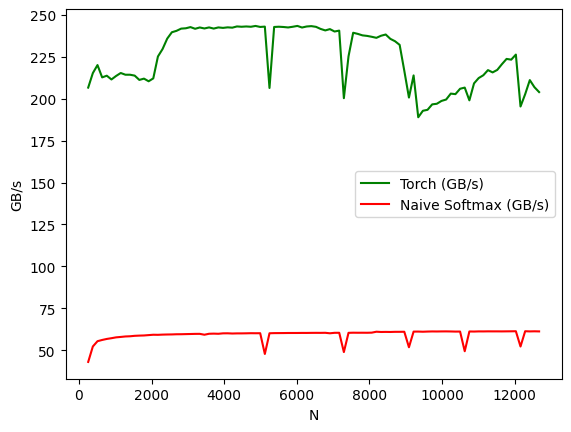

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['torch', 'naive_softmax'],  # possible values for `line_arg``
        line_names=["Torch", "Naive Softmax"],  # label name for the lines
        styles=[ ('green', '-'), ('red', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'naive_softmax':
        ms = triton.testing.do_bench(lambda: naive_softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


benchmark.run(show_plots=True)

#### A short digression on array strides

Before we write the kernel, a very short note on strides

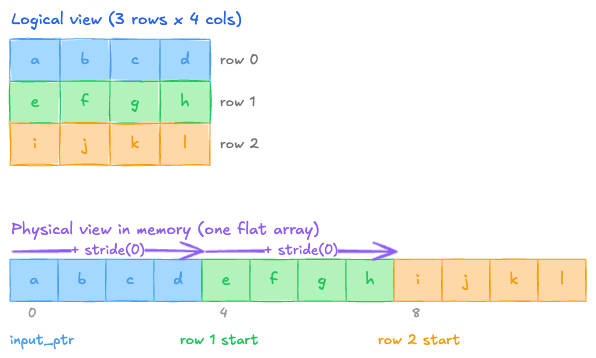

**Why not directly use number of columns?**

You could, but that also assumes that the matrix is contiguous in memory. It may not be!

Using strides lets tensor libraries also treat operations like transpose and slicing arrays "free" (memory views instead of copies)

Plus with multidimensional tensors it is easier to keep track of strides separately than try to calculate them manually from dimensions even for contiguous arrays.

*Further reading: An Illustrated Guide to Shapes and Strides* [Part 1](https://ajcr.net/stride-guide-part-1/), [Part 2](https://ajcr.net/stride-guide-part-2/), and [Part 3](https://ajcr.net/stride-guide-part-3/)

### Ex 3.2 The Softmax (forward pass) kernel

In [ ]:
@triton.jit
def softmax_kernel(output_ptr,
                   input_ptr,
                   input_row_stride,
                   output_row_stride,
                   n_cols,
                   BLOCK_SIZE: tl.constexpr):
    row_idx = tl.program_id(0) # <--- one program = one row

    # Indexing
    row_start_ptr = input_ptr + None # <---- Q. How do we index into the start of this row?
    col_offsets = tl.arange(0, None) # <---- Q. How do we get the span of this row?
    input_ptrs = row_start_ptr + col_offsets

    mask = col_offsets < n_cols

    row = tl.load(input_ptrs, mask=mask, other=-float('inf')) # row → SRAM, once
    # Note that the other sets default values over the mask, verify why -inf makes sense here

    row_minus_max = row - tl.max(row, axis=0)
    numerator = tl.exp(row_minus_max)
    denominator = tl.sum(numerator, axis=0)
    softmax_output = numerator / denominator

    output_row_start_ptr = output_ptr + None # <---- Q. How do we index into the start of the relevant output row?
    output_ptrs = output_row_start_ptr + col_offsets
    tl.store(output_ptrs, softmax_output, mask=mask)  # SRAM → HBM, once

In [ ]:
#@title Click to reveal the solution
@triton.jit
def softmax_kernel(output_ptr,
                   input_ptr,
                   input_row_stride,
                   output_row_stride,
                   n_cols,
                   BLOCK_SIZE: tl.constexpr):
    row_idx = tl.program_id(0) # <--- one program = one row

    # Indexing
    row_start_ptr = input_ptr + row_idx * input_row_stride # <---- Q. How do we index into the start of this row?
    col_offsets = tl.arange(0, BLOCK_SIZE) # <---- Q. How do we get the span of this row?
    input_ptrs = row_start_ptr + col_offsets

    mask = col_offsets < n_cols

    row = tl.load(input_ptrs, mask=mask, other=-float('inf')) # row → SRAM, once
    # Note that the other sets default values over the mask, verify why -inf makes sense here

    row_minus_max = row - tl.max(row, axis=0)
    numerator = tl.exp(row_minus_max)
    denominator = tl.sum(numerator, axis=0)
    softmax_output = numerator / denominator

    output_row_start_ptr = output_ptr + row_idx * output_row_stride # <---- Q. How do we index into the start of the relevant output row?
    output_ptrs = output_row_start_ptr + col_offsets
    tl.store(output_ptrs, softmax_output, mask=mask)  # SRAM → HBM, once

### 3.3 The Driver Function

In [ ]:
def softmax(x):
    n_rows, n_cols = x.shape
    BLOCK_SIZE = triton.next_power_of_2(n_cols)   # whole row fits one block
    y = torch.empty_like(x)
    grid = (n_rows, )                              # one program per row
    softmax_kernel[grid](y, x, x.stride(0), y.stride(0), n_cols, BLOCK_SIZE=BLOCK_SIZE)
    return y

In [ ]:
# Correctness check
x = torch.randn(1823, 781, device=DEVICE, dtype=torch.float32)
ref = torch.softmax(x, axis=-1)

print("naive  vs torch:", torch.allclose(naive_softmax(x), ref, atol=1e-5))
print("triton vs torch:", torch.allclose(softmax(x),       ref, atol=1e-5))

naive  vs torch: True
triton vs torch: True


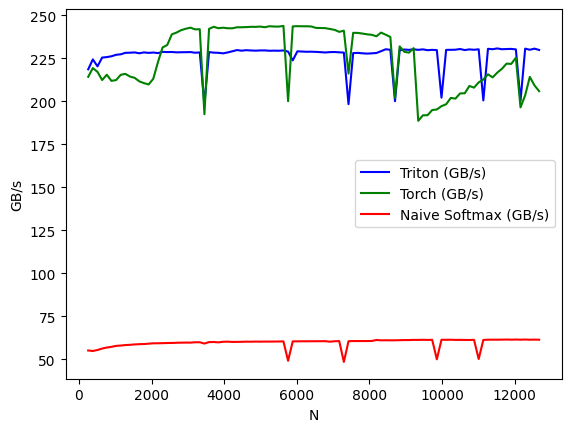

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch', 'naive_softmax'],  # possible values for `line_arg``
        line_names=["Triton", "Torch", "Naive Softmax"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    if provider == 'naive_softmax':
        ms = triton.testing.do_bench(lambda: naive_softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


benchmark.run(show_plots=True)

## Section 4. Online Softmax

### 4.1. The Problem with one-shot Softmax

Consider a standard multi-head scaled dot product attention. The score matrix is O($N^2$) where N is the sequence length. Let's look at what happens to the size of the score matrix S as we scale up the sequence length.

In [ ]:
bytes_per_elem = 4  # fp32

print(f"{'context (N)':>14} {'S elements':>16} {'S size / head':>16}")
for N in [4_096, 16_384, 32_768, 131_072]:
    elems = N * N
    size_gb = elems * bytes_per_elem / 1e9
    if size_gb < 1:
        print(f"{N:>14,} {elems:>16,} {size_gb*1000:>13.0f} MB")
    else:
        print(f"{N:>14,} {elems:>16,} {size_gb:>13.1f} GB")

   context (N)       S elements    S size / head
         4,096       16,777,216            67 MB
        16,384      268,435,456           1.1 GB
        32,768    1,073,741,824           4.3 GB
       131,072   17,179,869,184          68.7 GB


Materializing the score matrix is impossible for large context lengths, but even at reasonable context lenghts e.g. 16K the matrix is big enough where moving it back and forth from DRAM for softmax calculation would incur significant memory bandwidth costs.

But we mentioned earlier the need for subtracting the row max for algorithmic stability. The reason is that the `exp()` operation overflows quickly for large values. Let's see what happens without subtracting the row max.

In [ ]:
def unstable_softmax(x):
    e = torch.exp(x)  # <---- No row max subtraction
    return e / e.sum(dim=-1, keepdim=True)

x = torch.tensor([[1.0, 2.0, 1000.0]], device=DEVICE)
print("unstable:", unstable_softmax(x))  # <---- exp(1000) = inf
print("torch:   ", torch.softmax(x, dim=-1))

unstable: tensor([[0., 0., nan]], device='cuda:0')
torch:    tensor([[0., 0., 1.]], device='cuda:0')


We also need to calculate the demoninator for the full row, so if we are doing it online then we need to make sure that the calculation is correct. So how do we implement a safe and correct online softmax?

### Ex 4.2 Online Softmax in PyTorch

In [ ]:
def online_softmax(x):      # x: (N,) a single row, for clarity
    BLOCK = 128
    m = torch.tensor(-float('inf'))
    d = torch.tensor(0.0)
    # PASS 1: one streaming pass for max + denominator together
    for start in range(0, x.numel(), BLOCK):
        block = x[start:start+BLOCK]
        m_new = torch.maximum(m, block.max())
        # rescale the running denominator to the new max, then add
        # this block's contribution (computed relative to m_new)
        d = d * None + None # <-- fill in the rescaled denominator
        m = m_new
    # PASS 2: now we have final m, d — compute outputs
    return torch.exp(x - m) / d

In [ ]:
#@title Click to reveal the solution
def online_softmax(x):                 # x: (N,) a single row, for clarity
    BLOCK = 128
    m = torch.tensor(-float('inf'))
    d = torch.tensor(0.0)
    # PASS 1: one streaming pass for max + denominator together
    for start in range(0, x.numel(), BLOCK):
        block = x[start:start+BLOCK]
        m_new = torch.maximum(m, block.max())
        d = d * torch.exp(m - m_new) + torch.exp(block - m_new).sum()  # <-- the rescale
        m = m_new
    # PASS 2: now we have final m, d — compute outputs
    return torch.exp(x - m) / d


In [ ]:
row = torch.randn(4000, device=DEVICE) * 50
print("online vs torch:", torch.allclose(online_softmax(row),
                                         torch.softmax(row, dim=-1),
                                         atol=1e-5))

torch.Size([4000])
online vs torch: True


### 4.3 Online Softmax Kernel

In [ ]:
@triton.jit
def online_softmax_kernel(
        output_ptr,
        input_ptr,
        input_row_stride,
        output_row_stride,
        n_cols,
        BLOCK_SIZE: tl.constexpr):

    row_idx = tl.program_id(0)        # one program = one row
    input_row_start = input_ptr + row_idx * input_row_stride
    output_row_start = output_ptr + row_idx * output_row_stride

    # ============================================================
    # PASS 1: stream the row in tiles, maintaining running max (m)
    #         and running denominator (d) together. The row is
    #         NEVER fully resident — only one tile at a time.
    # ============================================================
    m = -float('inf')  # <----- running max (scalar)
    d = 0.0            # <----- running denom (scalar)

    # iterate over column in tiles of blocks
    for start in tl.range(0, n_cols, BLOCK_SIZE):
        cols = start + tl.arange(0, BLOCK_SIZE)
        mask = cols < n_cols
        block = tl.load(input_row_start + cols, mask=mask, other=-float('inf'))

        block_max = tl.max(block, axis=0)
        m_new = tl.maximum(m, block_max)  # <-----  new running max
        # rescale old denom to the new max, then add this tile's contribution
        d = d * tl.exp(m - m_new) + tl.sum(tl.exp(block - m_new), axis=0)
        m = m_new

    # ============================================================
    # PASS 2: we now have the FINAL m and d for the whole row.
    #         Re-stream the same tiles, normalize, and write out.
    #         (This re-reads the row from HBM a second time.)
    # ============================================================

    # iterate over column in tiles of blocks
    for start in tl.range(0, n_cols, BLOCK_SIZE):
        cols = start + tl.arange(0, BLOCK_SIZE)
        mask = cols < n_cols
        block = tl.load(input_row_start + cols, mask=mask, other=-float('inf'))
        out = tl.exp(block - m) / d
        tl.store(output_row_start + cols, out, mask=mask)

In [ ]:
def online_softmax_triton(x):
    n_rows, n_cols = x.shape
    BLOCK_SIZE = 1024      # FIXED tile width, not dependent on n_cols
    y = torch.empty_like(x)
    grid = (n_rows,)
    online_softmax_kernel[grid](
        y, x, x.stride(0), y.stride(0), n_cols, BLOCK_SIZE=BLOCK_SIZE)
    return y

In [ ]:
x = torch.randn(1823, 781, device=DEVICE, dtype=torch.float32) * 50
ref = torch.softmax(x, dim=-1)
print("triton online vs torch:", torch.allclose(online_softmax_triton(x), ref, atol=1e-4))

# Handling a row WIDER than BLOCK_SIZE
x_wide = torch.randn(64, 5000, device=DEVICE, dtype=torch.float32) * 50   # 5000 > 1024
ref = torch.softmax(x_wide, dim=-1)
print("wide row vs torch:     ", torch.allclose(online_softmax_triton(x_wide), ref, atol=1e-4))

triton online vs torch: True
wide row vs torch:      True
